# LINE MAN Wongnai — Pricing Assessment, Quiz 3

**Goal:** decompose the delivery fee into its two structural components — a static **base fee** and a dynamic **surge** — and characterise each.

**Dataset:** `Copy of delivery_fee_movement.csv` — 217,222 rows of `(date, city, restaurant_id, distance_km, delivery_fee)` covering March 2025, two cities (Omaha, Chattanooga), 1,000 restaurants, distance 0–9 km.

**Model:**
$$\text{fee}(r, d, k) = \text{base}(r, k) + \text{surge}(r, d)$$
where $r$ = restaurant, $d$ = date, $k$ = distance in km. We fit it with two-way alternating least squares, then anchor so that each restaurant's minimum observed surge = $0 (i.e. assume every restaurant has at least one zero-surge day in the month).

Notebook is structured as:
1. Load & inspect
2. Verify the additive base+surge hypothesis
3. Fit the decomposition (ALS)
4. Section 3.1 — dynamic surge analysis
5. Section 3.2 — base fee analysis & one-week snapshot

## 1. Load & inspect

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option('display.max_rows', 40)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

HERE = Path.cwd()
CHARTS = HERE / 'charts'
CHARTS.mkdir(exist_ok=True)

df = pd.read_csv('Copy of delivery_fee_movement.csv')
df.columns = ['date', 'city', 'rid', 'km', 'fee']
df['date'] = pd.to_datetime(df['date'])
print('Shape:', df.shape)
df.head()

Shape: (217222, 5)


,date,city,rid,km,fee
0,2025-03-01,Omaha,0,0,4.250
1,2025-03-01,Omaha,0,3,4.750
2,2025-03-01,Omaha,0,5,5.750
3,2025-03-01,Omaha,0,6,6.250
4,2025-03-01,Omaha,0,8,7.250


In [2]:
print('Date range :', df['date'].min().date(), '→', df['date'].max().date())
print('Cities     :', df['city'].unique())
print('Restaurants:', df['rid'].nunique())
print('Distances  :', sorted(df['km'].unique()))
print('Restaurants per city:'); print(df.groupby('city')['rid'].nunique())
print('\nFee describe:'); print(df['fee'].describe().round(3))

Date range : 2025-03-01 → 2025-03-31
Cities     : ['Omaha' 'Chattanooga']
Restaurants: 1000
Distances  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restaurants per city:
city
Chattanooga    487
Omaha          513
Name: rid, dtype: int64

Fee describe:
count   217222.000
mean         4.840
std          1.809
min          2.000
25%          3.500
50%          5.000
75%          6.000
max         12.000
Name: fee, dtype: float64


In [3]:
# What does the fee curve look like for one restaurant across all dates and distances?
sub = df[(df['city']=='Omaha') & (df['rid']==0)]
sub.pivot_table(index='date', columns='km', values='fee').head(12)

km,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
2025-03-01,4.250,NaN,NaN,4.750,NaN,5.750,6.250,NaN,7.250,NaN
2025-03-02,3.500,3.500,3.500,4.000,4.500,5.000,5.500,6.000,NaN,NaN
2025-03-03,2.000,2.000,2.000,2.500,NaN,3.500,4.000,4.500,NaN,NaN
2025-03-04,2.000,2.000,2.000,2.500,3.000,3.500,4.000,4.500,5.000,5.500
2025-03-05,2.000,2.000,2.000,2.500,3.000,3.500,4.000,4.500,5.000,NaN
2025-03-06,2.000,2.000,2.000,NaN,3.000,3.500,4.000,4.500,5.000,NaN
2025-03-07,3.000,3.000,3.000,3.500,4.000,4.500,5.000,5.500,NaN,6.500
2025-03-08,4.750,4.750,4.750,5.250,NaN,NaN,6.750,NaN,NaN,NaN
2025-03-09,4.500,4.500,4.500,5.000,5.500,6.000,6.500,NaN,7.500,8.000


**Observation.** For restaurant 0 in Omaha:

- Mar 03–6, 10 show the same low values across km — the **base** schedule.
- Mar 01, 02, 07, 08, 09 are all uniformly *higher* by an integer fraction of $0.25 across every distance — that uniform offset is the **surge**.

This is the visual fingerprint of an **additive base+surge structure**, and motivates the model below.

## 2. Verify the hypothesis

If `fee = base(rid, km) + surge(rid, date)` is true, then for each `(rid, date)` group, `fee − base(rid, km)` should be a single constant (= the surge for that day). We don't know the true base yet, but we can approximate it with `min` across dates and check that the implied surge is constant within each `(rid, date)`.

In [4]:
df['base_min'] = df.groupby(['rid','km'])['fee'].transform('min')
df['surge_est'] = df['fee'] - df['base_min']

rng = df.groupby(['rid','date'])['surge_est'].agg(lambda s: s.max()-s.min())
print('Within-group surge range stats:'); print(rng.describe().round(4))
print('\n% of (rid, date) groups with constant surge across km:', f'{(rng < 1e-9).mean()*100:.2f}%')

Within-group surge range stats:
count   31000.000
mean        0.010
std         0.119
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         2.750
Name: surge_est, dtype: float64

% of (rid, date) groups with constant surge across km: 99.13%


**99%+ of restaurant-days have a perfectly constant implied surge across distance.** The remainder are explained by edge cases where the cheapest observed fee for some `(rid, km)` was already on a low-surge (not zero-surge) day, biasing the `min`-based base estimate. We fix this with a proper joint fit next.

## 3. Decompose via two-way ALS

Alternate:
1. `base(rid, km) = mean over dates of (fee − surge)`
2. `surge(rid, date) = mean over km of (fee − base)`

Iterate to convergence, then **anchor** so the minimum surge per restaurant is $0.

In [5]:
df = df[['date','city','rid','km','fee']].copy()
df['surge'] = 0.0

for it in range(20):
    base = (df.groupby(['rid','km'], group_keys=False)
              .apply(lambda g: (g['fee'] - g['surge']).mean(), include_groups=False)
              .rename('base').reset_index())
    df = df.drop(columns=['base'], errors='ignore').merge(base, on=['rid','km'])
    surge = (df.groupby(['rid','date'], group_keys=False)
               .apply(lambda g: (g['fee'] - g['base']).mean(), include_groups=False)
               .rename('surge_new').reset_index())
    df = df.drop(columns=['surge_new'], errors='ignore').merge(surge, on=['rid','date'])
    df['surge'] = df['surge_new']
    df = df.drop(columns=['surge_new'])

# Anchor: min surge per restaurant → 0
min_surge = df.groupby('rid')['surge'].transform('min')
df['surge'] = df['surge'] - min_surge
df['base'] = df['base'] + min_surge

# Snap to the $0.25 grid (removes ALS float noise)
df['base'] = (df['base'] * 4).round() / 4
df['surge'] = (df['surge'] * 4).round() / 4

df['pred'] = df['base'] + df['surge']
df['resid'] = df['fee'] - df['pred']
r2 = 1 - df['resid'].var() / df['fee'].var()
print(f'Residual max abs: {df["resid"].abs().max():.6f}')
print(f'R²              : {r2:.6f}')
print('\nBase describe:'); print(df['base'].describe().round(3))
print('\nSurge describe:'); print(df['surge'].describe().round(3))

Residual max abs: 0.000000
R²              : 1.000000

Base describe:
count   217222.000
mean         4.133
std          1.508
min          2.000
25%          3.000
50%          4.000
75%          5.000
max          8.500
Name: base, dtype: float64

Surge describe:
count   217222.000
mean         0.707
std          0.834
min          0.000
25%          0.000
50%          0.500
75%          1.000
max          3.500
Name: surge, dtype: float64


**R² = 1.000.** The fee is exactly the sum of `base(rid, km)` and `surge(rid, date)` — no multiplicative interaction, no missing third factor. We can analyse the two pieces independently from here.

In [6]:
# Persist the decomposition for downstream use
df.to_parquet('decomposed.parquet', index=False)

## Headline composition

In [7]:
mean_fee, mean_base, mean_surge = df['fee'].mean(), df['base'].mean(), df['surge'].mean()
print(f'Mean total fee : ${mean_fee:.3f}')
print(f'Mean base fee  : ${mean_base:.3f}  ({mean_base/mean_fee*100:.1f}% of total)')
print(f'Mean surge     : ${mean_surge:.3f}  ({mean_surge/mean_fee*100:.1f}% of total)')
print(f'% rows with surge>0 : {(df["surge"]>0).mean()*100:.1f}%')

active = df.loc[df['surge']>0, 'surge']
print(f'\nSurge when active: mean ${active.mean():.2f} | median ${active.median():.2f}'
      f' | p90 ${active.quantile(0.9):.2f} | max ${active.max():.2f}')

Mean total fee : $4.840
Mean base fee  : $4.133  (85.4% of total)
Mean surge     : $0.707  (14.6% of total)
% rows with surge>0 : 52.8%

Surge when active: mean $1.34 | median $1.00 | p90 $2.50 | max $3.50


## 3.1 Dynamic surge

### 3.1.1 Isolate surge from base

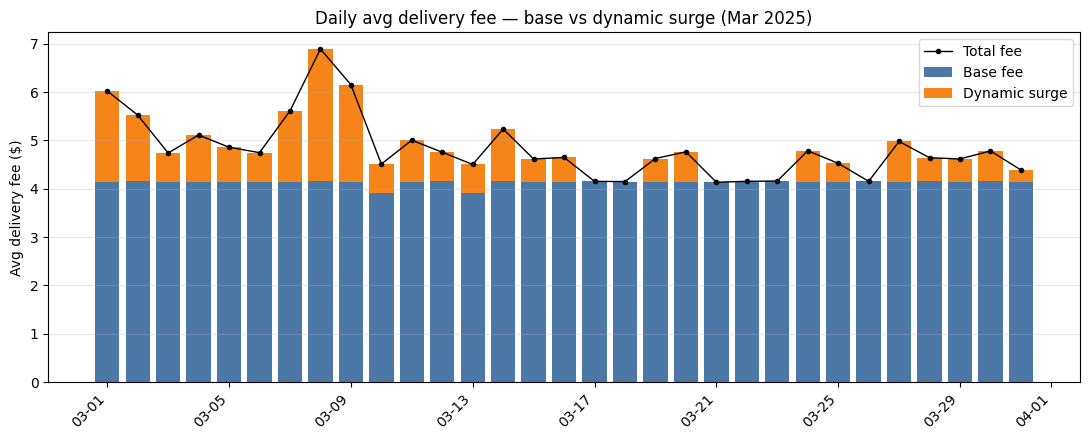

,fee,base,surge
date,,,
2025-03-01,6.023,4.148,1.874
2025-03-02,5.523,4.155,1.369
2025-03-03,4.739,4.143,0.597
2025-03-04,5.111,4.145,0.966
2025-03-05,4.858,4.141,0.717
2025-03-06,4.747,4.141,0.605
2025-03-07,5.609,4.136,1.474
2025-03-08,6.891,4.151,2.740
2025-03-09,6.153,4.146,2.006


In [8]:
daily = df.groupby('date').agg(fee=('fee','mean'), base=('base','mean'), surge=('surge','mean'))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(daily.index, daily['base'], label='Base fee', color='#4C78A8')
ax.bar(daily.index, daily['surge'], bottom=daily['base'], label='Dynamic surge', color='#F58518')
ax.plot(daily.index, daily['fee'], color='black', marker='o', ms=3, lw=1, label='Total fee')
ax.set_ylabel('Avg delivery fee ($)')
ax.set_title('Daily avg delivery fee — base vs dynamic surge (Mar 2025)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(); ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.savefig(CHARTS / '01_daily_decomposition.png', dpi=130)
plt.show()

daily.round(3)

**Reading.** The blue (base) layer is essentially flat at ~$4.13 across the entire month — day-to-day movement in headline fee is **entirely surge-driven**. Six days have zero surge: Mar 17, 18, 21, 22, 23, 26. The peak surge day is Mar 8 (Saturday).

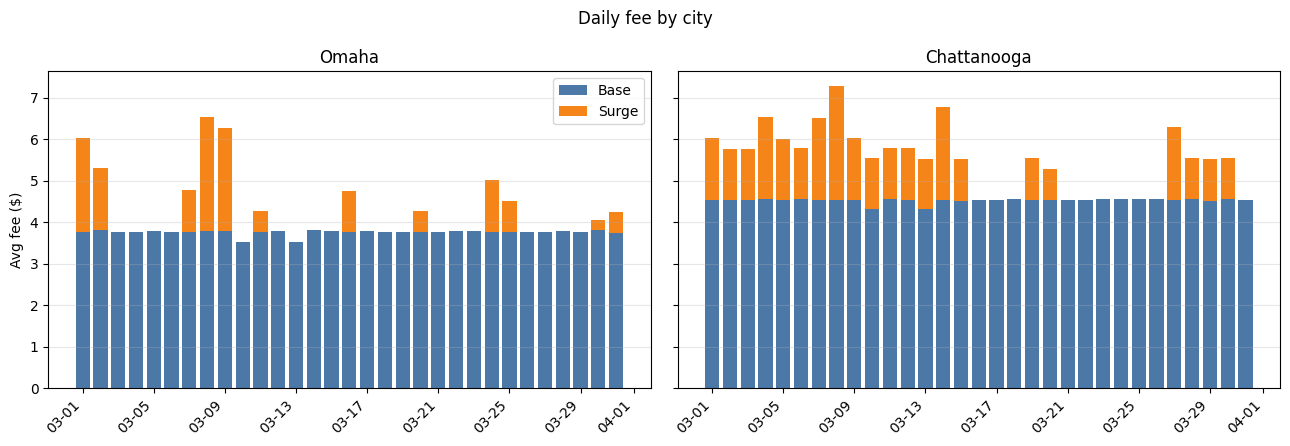

              fee  base  surge  surge_freq
city                                      
Chattanooga 5.474 4.528  0.946       0.673
Omaha       4.239 3.759  0.480       0.391


In [9]:
# By city
dc = (df.groupby(['date','city'])
        .agg(fee=('fee','mean'), base=('base','mean'), surge=('surge','mean'))
        .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, c in zip(axes, ['Omaha','Chattanooga']):
    s = dc[dc.city==c].set_index('date').sort_index()
    ax.bar(s.index, s['base'], label='Base', color='#4C78A8')
    ax.bar(s.index, s['surge'], bottom=s['base'], label='Surge', color='#F58518')
    ax.set_title(c)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(alpha=.3, axis='y')
axes[0].set_ylabel('Avg fee ($)'); axes[0].legend()
fig.suptitle('Daily fee by city')
plt.tight_layout()
plt.savefig(CHARTS / '02_daily_by_city.png', dpi=130)
plt.show()

city_summary = df.groupby('city').agg(
    fee=('fee','mean'), base=('base','mean'), surge=('surge','mean'),
    surge_freq=('surge', lambda s: (s>0).mean())
).round(3)
print(city_summary)

### 3.1.2 Surge behaviour — patterns

       n_rows    pct
surge               
0.250    3664  3.200
0.500   10912  9.500
0.750    7057  6.100
1.000   42270 36.800
1.250   11525 10.000
1.500    3675  3.200
1.750    8763  7.600
2.000    7862  6.800
2.250    6020  5.200
2.500    6262  5.500
2.750    5192  4.500
3.000     793  0.700
3.500     791  0.700


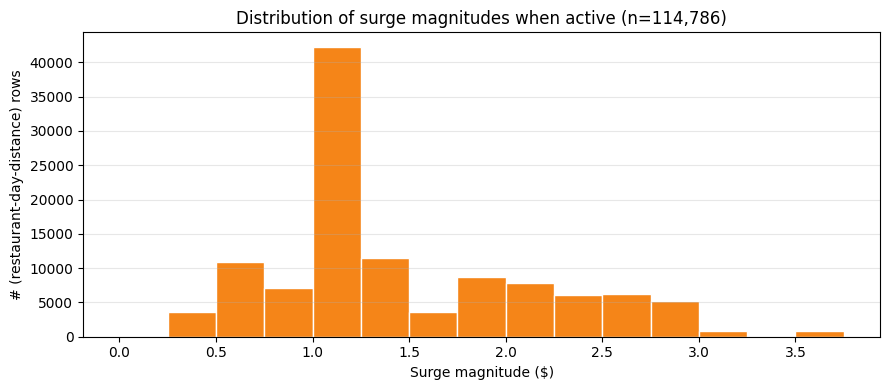

In [10]:
# Magnitude distribution (when active)
active = df.loc[df['surge']>0, 'surge']
magnitude = (active.value_counts().sort_index()
             .rename('n_rows').to_frame()
             .assign(pct=lambda x: (100*x.n_rows/x.n_rows.sum()).round(1)))
print(magnitude)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(active, bins=np.arange(0, 4, 0.25), color='#F58518', edgecolor='white')
ax.set_xlabel('Surge magnitude ($)')
ax.set_ylabel('# (restaurant-day-distance) rows')
ax.set_title(f'Distribution of surge magnitudes when active (n={len(active):,})')
ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.savefig(CHARTS / '04_surge_histogram.png', dpi=130)
plt.show()

           avg_surge  surge_freq
dow                             
Monday         0.411       0.395
Tuesday        0.553       0.500
Wednesday      0.451       0.364
Thursday       0.669       0.621
Friday         0.759       0.492
Saturday       1.119       0.595
Sunday         0.899       0.703


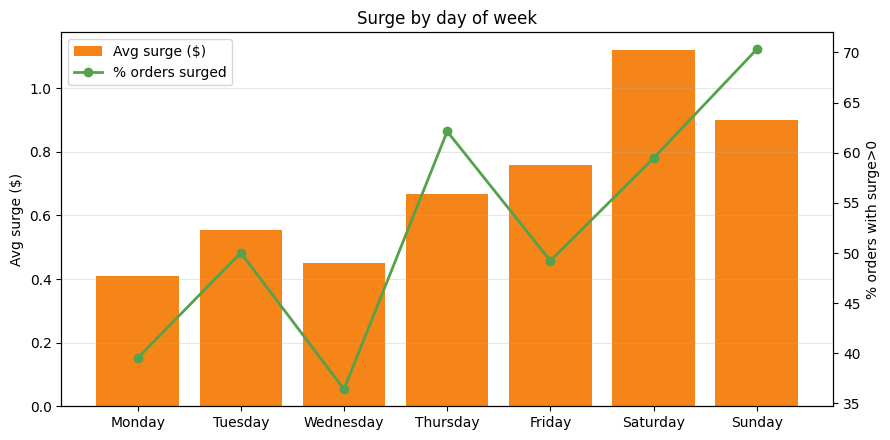

In [11]:
# By day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_ = df.assign(dow=df['date'].dt.day_name())
dow = df_.groupby('dow').agg(avg_surge=('surge','mean'),
                              surge_freq=('surge', lambda s:(s>0).mean())).reindex(dow_order)
print(dow.round(3))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(dow.index, dow['avg_surge'], color='#F58518', label='Avg surge ($)')
ax2 = ax1.twinx()
ax2.plot(dow.index, dow['surge_freq']*100, color='#54A24B', marker='o', lw=2, label='% orders surged')
ax1.set_ylabel('Avg surge ($)')
ax2.set_ylabel('% orders with surge>0')
ax1.set_title('Surge by day of week')
ax1.grid(alpha=.3, axis='y')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS / '03_surge_by_dow.png', dpi=130)
plt.show()

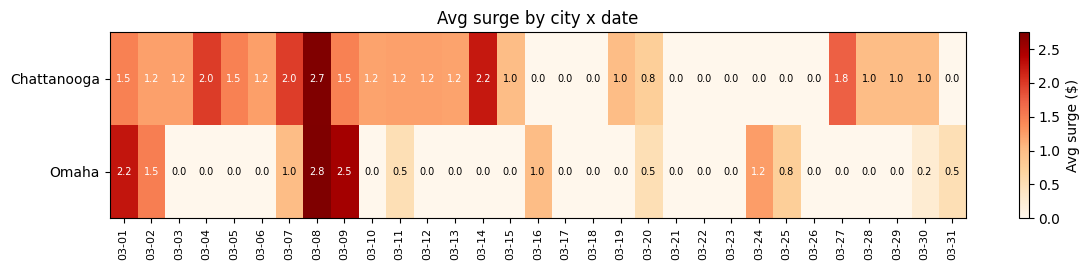

In [12]:
# Surge heatmap by city x date
pivot = df.groupby(['city','date'])['surge'].mean().unstack('date')

fig, ax = plt.subplots(figsize=(12, 2.8))
im = ax.imshow(pivot.values, aspect='auto', cmap='OrRd')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([d.strftime('%m-%d') for d in pivot.columns], rotation=90, fontsize=8)
for (i, j), v in np.ndenumerate(pivot.values):
    ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
            color='white' if v>1.0 else 'black')
plt.colorbar(im, ax=ax, label='Avg surge ($)')
ax.set_title('Avg surge by city x date')
plt.tight_layout()
plt.savefig(CHARTS / '07_surge_heatmap.png', dpi=130)
plt.show()

**Key surge patterns**

- **Granularity:** surge fires on a discrete $0.25 grid, modal value $1.00 (37% of surged rows). Suggests a quantised tier system, not a free-floating multiplier.
- **Weekend skew:** Sat avg surge $1.12, Sun $0.90, vs Mon $0.41 and Wed $0.45. Sunday also has the highest surge-frequency (70% of orders).
- **Two "regimes":** ~8 "full activation" days (every order surged) and 6 "zero surge" days. The other days sit at ~50% surge frequency — consistent with polygon-level (not city-level) triggers.
- **City split:** Chattanooga surges far more often than Omaha (67% vs 39% of orders) and at a higher mean magnitude.

## 3.2 Standard base fee

### 3.2.1 Movement of the base fee over time

In [13]:
# Stability check: does base vary for a (restaurant, km) across dates?
stability = df.groupby(['rid','km'])['base'].std()
print('Std of base within (rid, km) across dates:'); print(stability.describe().round(6))

# Daily mean of base (the small wobble is from which restaurants were sampled, not real movement)
daily_base = df.groupby('date')['base'].mean().round(3)
print('\nDaily mean base (range):', daily_base.min(), '→', daily_base.max(),
      f'(spread ${daily_base.max()-daily_base.min():.3f})')

Std of base within (rid, km) across dates:
count   9951.000
mean       0.000
std        0.000
min        0.000
25%        0.000
50%        0.000
75%        0.000
max        0.000
Name: base, dtype: float64

Daily mean base (range): 3.913 → 4.166 (spread $0.253)


**Conclusion.** Std of base within `(rid, km)` is zero — the base fee is **completely static across the month**. The small daily wobble in the city-mean base ($3.91 to $4.17) is purely a sampling artefact: the set of (restaurant, km) combinations observed each day is different.

### 3.2.2 One-week snapshot of the base fee (surge excluded)

We choose **Mon 2025-03-17 to Sun 2025-03-23** — 5 of 7 days have zero surge in this window, so this is the cleanest base-only week. Because we already have the decomposition, we simply read the `base` column — surge is fully excluded by construction.

In [14]:
week = df[(df['date']>='2025-03-17') & (df['date']<='2025-03-23')]
print('Surge in chosen week (should be small):')
print(week.groupby('date')['surge'].mean().round(3))

snap = week.groupby(['city','km'])['base'].agg(['mean','median','min','max']).round(2)
print('\nBase fee snapshot (Mar 17-23) by city and km:')
print(snap)

Surge in chosen week (should be small):
date
2025-03-17   0.000
2025-03-18   0.000
2025-03-19   0.488
2025-03-20   0.621
2025-03-21   0.000
2025-03-22   0.000
2025-03-23   0.000
Name: surge, dtype: float64

Base fee snapshot (Mar 17-23) by city and km:
                mean  median   min   max
city        km                          
Chattanooga 0  3.600   3.000 3.000 5.000
            1  3.570   3.000 3.000 5.000
            2  3.560   3.000 3.000 5.000
            3  4.020   3.500 3.500 5.500
            4  4.480   4.000 4.000 6.000
            5  4.940   4.500 4.500 6.500
            6  5.400   5.000 5.000 7.000
            7  5.800   5.500 5.500 7.500
            8  6.250   6.000 6.000 8.000
            9  6.630   6.500 6.500 8.500
Omaha       0  2.890   2.000 2.000 5.000
            1  2.860   2.000 2.000 5.000
            2  2.830   2.000 2.000 5.000
            3  3.260   2.500 2.500 5.500
            4  3.730   3.000 3.000 6.000
            5  4.140   3.500 3.500 6.500
         

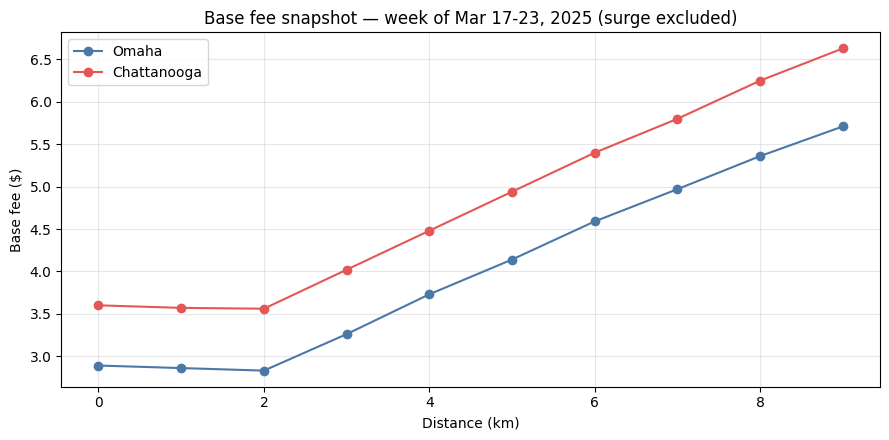

In [15]:
# Snapshot chart
fig, ax = plt.subplots(figsize=(9, 4.5))
for c, col in [('Omaha','#4C78A8'),('Chattanooga','#E45756')]:
    s = snap.xs(c, level='city').reset_index()
    ax.plot(s['km'], s['mean'], '-o', color=col, label=c)
ax.set_xlabel('Distance (km)'); ax.set_ylabel('Base fee ($)')
ax.set_title('Base fee snapshot — week of Mar 17-23, 2025 (surge excluded)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(CHARTS / '06_week_snapshot.png', dpi=130)
plt.show()

In [16]:
# Restaurant-level archetypes: every restaurant follows the same shape, only the intercept differs
b0 = df[df['km']==0].groupby(['city','rid'])['base'].first().reset_index()
print('Base fee at km=0 (the flat-zone fee) — restaurant counts by city:')
print(b0.groupby(['city','base']).size().rename('n').unstack(fill_value=0))
print('\nShare (%):')
print(b0.groupby(['city','base']).size().unstack(fill_value=0)
         .apply(lambda x: (100*x/x.sum()).round(1), axis=1))

Base fee at km=0 (the flat-zone fee) — restaurant counts by city:
base         2.000  3.000  5.000
city                            
Chattanooga      0    342    145
Omaha          361      0    152

Share (%):
base         2.000  3.000  5.000
city                            
Chattanooga  0.000 70.200 29.800
Omaha       70.400  0.000 29.600


In [17]:
# Verify the universal +$0.50/km slope and the 3 km flat zone
rest_base = df.groupby(['city','rid','km'])['base'].first().reset_index()

def slope_from_km3(g):
    s = g[g['km']>=3].sort_values('km')
    if len(s) < 2: return np.nan
    return np.polyfit(s['km'], s['base'], 1)[0]

slopes = rest_base.groupby(['city','rid'], group_keys=False).apply(slope_from_km3, include_groups=False).rename('slope_per_km').reset_index()
print('Per-km slope (km>=3) across all 1,000 restaurants:')
print(slopes.groupby('city')['slope_per_km'].describe().round(3))

# When does the fee first step up from the km=0 value?
def first_step_km(g):
    g = g.sort_values('km').reset_index(drop=True)
    b0 = g['base'].iloc[0]
    for _, r in g.iterrows():
        if r['base'] > b0 + 1e-6:
            return int(r['km'])
    return None

step = rest_base.groupby(['city','rid'], group_keys=False).apply(first_step_km, include_groups=False).rename('first_step_km').reset_index()
print('\nKm at which fee first steps up from the flat zone:')
print(step.groupby(['city','first_step_km']).size().unstack(fill_value=0))

Per-km slope (km>=3) across all 1,000 restaurants:
              count  mean   std   min   25%   50%   75%   max
city                                                         
Chattanooga 487.000 0.500 0.000 0.500 0.500 0.500 0.500 0.500
Omaha       513.000 0.500 0.000 0.500 0.500 0.500 0.500 0.500

Km at which fee first steps up from the flat zone:
first_step_km    3
city              
Chattanooga    487
Omaha          513


**Three archetypes account for all 1,000 restaurants:**

| Archetype | Flat-zone fee (km 0-2) | km 9 fee | Cities | # restaurants |
|---|---|---|---|---|
| Standard - Omaha | $2.00 | $5.50 | Omaha only | 361 (70% of Omaha) |
| Standard - Chattanooga | $3.00 | $6.50 | Chattanooga only | 342 (70% of Chattanooga) |
| Premium | $5.00 | $8.50 | Both | 152 Omaha + 145 Chattanooga (~30%) |

All restaurants share the same **slope ($0.50 per km from km 3)** and the same **3 km flat zone** — only the *intercept* differs. So the base-fee schedule is set by **rule (city + tier)**, not negotiated per restaurant. That is operationally clean and easy to A/B.

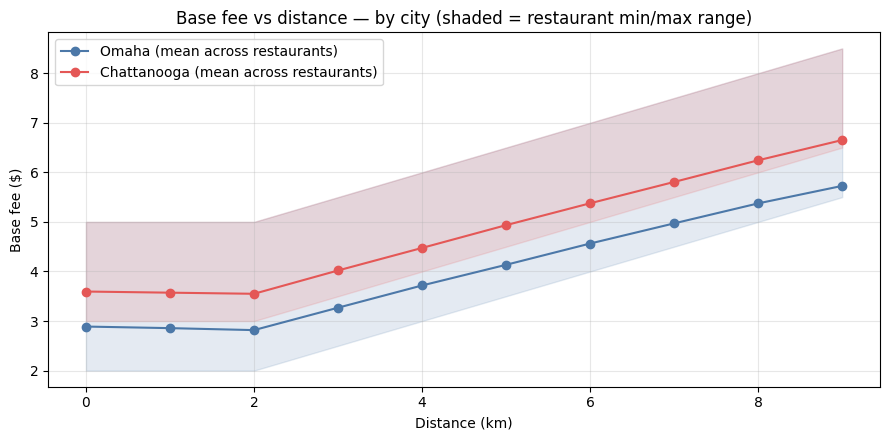

In [18]:
# Final base curve chart (all 31 days)
base_curve = df.groupby(['city','km'])['base'].agg(['mean','min','max']).reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c, col in [('Omaha','#4C78A8'),('Chattanooga','#E45756')]:
    s = base_curve[base_curve.city==c]
    ax.plot(s['km'], s['mean'], '-o', color=col, label=f'{c} (mean across restaurants)')
    ax.fill_between(s['km'], s['min'], s['max'], color=col, alpha=0.15)
ax.set_xlabel('Distance (km)'); ax.set_ylabel('Base fee ($)')
ax.set_title('Base fee vs distance — by city (shaded = restaurant min/max range)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(CHARTS / '05_base_vs_distance.png', dpi=130)
plt.show()

## Summary

- **Model fits exactly** (R² = 1.000): `fee = base(rid, km) + surge(rid, date)`.
- **Base fee is static** across the month and follows one of **3 archetypes**: $2 (Omaha standard), $3 (Chattanooga standard), $5 (Premium). All share a 3 km flat zone and $0.50/km step.
- **Surge** is on a $0.25 grid, modal $1.00, fires on 53% of orders. Weekend-heavy (Sat $1.12, Sun $0.90 avg vs Mon $0.41).
- **Base is 85.4%**, **surge 14.6%** of the average $4.84 fee. Chattanooga has higher base *and* higher surge frequency than Omaha.

See `assessment_response.md` for the written narrative covering Quizzes 1, 2, and 3 together.